# Deterministic U-Net baseline — final validation diagnostics

This notebook trains a small deterministic U-Net on the processed Iberian wildfire tensors, compares a pre-declared set of rare-event MSE weightings against climatology and persistence on the validation split, and keeps `mild_active2_tail2` as the selected deterministic U-Net baseline candidate.

The test split remains disabled by default. Use validation to document and lock the U-Net recipe; only enable test evaluation after the recipe is frozen.


## 0. Project choices for this baseline

Locked project choices carried forward:

- 32 × 54 Iberian grid, next-month burned-fraction target.
- K = 4 months of antecedent climate plus static covariates and calendar channels.
- Year-block split: train on the training years, validate on 2014 and 2019, reserve 2017 and 2022–2025 for final test only.
- Deterministic U-Net is a baseline against train-only climatology and persistence.

This final validation notebook keeps the small **validation-only loss-weight sweep** for reproducibility, but treats `mild_active2_tail2` as the selected deterministic U-Net candidate. Metrics are computed with the same unmodified area weights for every model, so the loss weighting affects training only, not evaluation.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import json
import math
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings("default")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42

def seed_everything(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BURN_THRESHOLD = 1e-6
LAND_THRESHOLD = 0.5
FIRE_SEASON_MONTHS = (7, 8, 9, 10)
EXTREME_Q = 0.99
HEADLINE_SUBSETS = ("all", "active_burned_gt_1e-6", "top_1pct_train_tail")
SELECTED_UNET_RUN_ID = "mild_active2_tail2"
SELECTED_UNET_MODEL = f"unet_{SELECTED_UNET_RUN_ID}"

BATCH_SIZE = 16
NUM_EPOCHS = 80
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 15
BASE_WIDTH = 32
DROPOUT = 0.05
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 0
USE_AREA_WEIGHTED_LOSS = True
USE_AMP = True
RUN_TEST_EVAL = True

# Default single-run values used only for dataset/model previews.
USE_EVENT_WEIGHTED_LOSS = False
ACTIVE_CELL_LOSS_WEIGHT = 1.0
TAIL_CELL_LOSS_WEIGHT = 1.0
FIRE_SEASON_LOSS_WEIGHT = 1.0
LOSS_WEIGHT_CLIP = 25.0

# Validation-only sweep. Keep this short to avoid over-tuning on just two validation years.
# The previous aggressive run (5, 10) is retained as a reference, but the final candidate
# should usually come from the raw/mild settings unless validation diagnostics strongly disagree.
LOSS_WEIGHT_SWEEP = [
    {
        "run_id": "raw_area_mse",
        "label": "Raw area-weighted MSE",
        "use_event_weighted_loss": False,
        "active_cell_loss_weight": 1.0,
        "tail_cell_loss_weight": 1.0,
        "fire_season_loss_weight": 1.0,
    },
    {
        "run_id": "mild_active2_tail2",
        "label": "Mild active=2 tail=2",
        "use_event_weighted_loss": True,
        "active_cell_loss_weight": 2.0,
        "tail_cell_loss_weight": 2.0,
        "fire_season_loss_weight": 1.0,
    },
    {
        "run_id": "mild_active2_tail5",
        "label": "Mild active=2 tail=5",
        "use_event_weighted_loss": True,
        "active_cell_loss_weight": 2.0,
        "tail_cell_loss_weight": 5.0,
        "fire_season_loss_weight": 1.0,
    },
    {
        "run_id": "medium_active3_tail5",
        "label": "Medium active=3 tail=5",
        "use_event_weighted_loss": True,
        "active_cell_loss_weight": 3.0,
        "tail_cell_loss_weight": 5.0,
        "fire_season_loss_weight": 1.0,
    },
    {
        "run_id": "aggressive_active5_tail10",
        "label": "Aggressive active=5 tail=10",
        "use_event_weighted_loss": True,
        "active_cell_loss_weight": 5.0,
        "tail_cell_loss_weight": 10.0,
        "fire_season_loss_weight": 1.0,
    },
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Sweep runs: {len(LOSS_WEIGHT_SWEEP)}")
display(pd.DataFrame(LOSS_WEIGHT_SWEEP))


Torch version: 2.11.0+cu130
Device: cuda
Sweep runs: 5


,run_id,label,use_event_weighted_loss,active_cell_loss_weight,tail_cell_loss_weight,fire_season_loss_weight
0,raw_area_mse,Raw area-weighted MSE,False,1.0,1.0,1.0
1,mild_active2_tail2,Mild active=2 tail=2,True,2.0,2.0,1.0
2,mild_active2_tail5,Mild active=2 tail=5,True,2.0,5.0,1.0
3,medium_active3_tail5,Medium active=3 tail=5,True,3.0,5.0,1.0
4,aggressive_active5_tail10,Aggressive active=5 tail=10,True,5.0,10.0,1.0


## 2. Locate processed tensors and output directories

In [2]:
def find_processed_data_dir() -> Path:
    """Find the processed data directory produced by the conditioning-tensor notebook."""
    env = os.environ.get("WILDFIRE_DATA_DIR")
    if env:
        return Path(env).expanduser().resolve()

    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "processed",
        cwd.parent / "data" / "processed",
        Path("/mnt/data/data/processed"),
    ]
    for candidate in candidates:
        if (candidate / "splits" / "train.nc").exists():
            return candidate.resolve()
    return (cwd / "data" / "processed").resolve()


DATA_DIR = find_processed_data_dir()
SPLIT_DIR = DATA_DIR / "splits"
SPLIT_FILES = {
    "train": SPLIT_DIR / "train.nc",
    "val": SPLIT_DIR / "val.nc",
    "test": SPLIT_DIR / "test.nc",
}
LSM_PATH = DATA_DIR / "static_lsm.nc"
IBERIAN_MASK_PATH = DATA_DIR / "static_iberian_mask.nc"
NORM_STATS_PATH = DATA_DIR / "norm_stats.json"

MODEL_DIR = DATA_DIR / "models" / "deterministic_unet"
FORECAST_DIR = DATA_DIR / "forecasts" / "deterministic_unet"
METRIC_DIR = DATA_DIR / "metrics"
FIGURE_DIR = DATA_DIR / "figures" / "deterministic_unet"
for path in [MODEL_DIR, FORECAST_DIR, METRIC_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

required_paths = [*SPLIT_FILES.values(), LSM_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing processed tensor files. Expected files under "
        f"{DATA_DIR}. Missing:\n" + "\n".join(missing)
    )

print(f"Using DATA_DIR  = {DATA_DIR}")
print(f"Model dir       = {MODEL_DIR}")
print(f"Forecast dir    = {FORECAST_DIR}")
print(f"Metric dir      = {METRIC_DIR}")
print(f"Figure dir      = {FIGURE_DIR}")
for name, path in SPLIT_FILES.items():
    print(f"{name:>5}: {path}")
print(f"  lsm: {LSM_PATH}")
print(f" mask: {IBERIAN_MASK_PATH}  # used if present; rebuilt if missing")

Using DATA_DIR  = C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed
Model dir       = C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\models\deterministic_unet
Forecast dir    = C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet
Metric dir      = C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\metrics
Figure dir      = C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\figures\deterministic_unet
train: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\splits\train.nc
  val: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\splits\val.nc
 test: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\splits\test.nc
  lsm: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\

## 3. Load the Iberian-domain mask and metric weights

In [3]:
def load_lsm(lsm_path: Path = LSM_PATH) -> xr.DataArray:
    """Load the static land-sea mask as a 2D DataArray sorted by latitude."""
    ds = xr.open_dataset(lsm_path)
    if "lsm" in ds.data_vars:
        da = ds["lsm"]
    else:
        da = ds[list(ds.data_vars)[0]]
    da = da.squeeze(drop=True)
    if "lat" in da.coords:
        da = da.sortby("lat")
    return da.astype("float32")


def _iberian_southern_boundary(lsm: xr.DataArray) -> xr.DataArray:
    """Heuristic southern boundary to remove North African coastal cells."""
    _, lon2d = xr.broadcast(lsm["lat"], lsm["lon"])
    boundary = xr.full_like(lon2d, 36.0, dtype="float32")
    boundary = xr.where((lon2d >= -5.5) & (lon2d < -2.0), 36.25, boundary)
    boundary = xr.where((lon2d >= -2.0) & (lon2d < 0.5), 36.50, boundary)
    boundary = xr.where((lon2d >= 0.5) & (lon2d < 1.5), 38.00, boundary)
    boundary = xr.where(lon2d >= 1.5, 38.50, boundary)
    boundary = boundary.rename("southern_boundary_lat")
    boundary.attrs["description"] = "Heuristic southern latitude boundary used to remove North African coastal cells."
    return boundary


def build_iberian_mask(lsm: xr.DataArray, land_threshold: float = LAND_THRESHOLD) -> xr.Dataset:
    """Build the reusable Iberian-domain mask on the processed 0.25° grid."""
    lsm = lsm.sortby("lat") if "lat" in lsm.coords else lsm
    lat2d, _ = xr.broadcast(lsm["lat"], lsm["lon"])
    southern_boundary = _iberian_southern_boundary(lsm)
    mask = ((lsm > land_threshold) & (lat2d >= southern_boundary)).astype("uint8").rename("iberian_mask")
    mask.attrs.update({
        "description": "Iberian-domain mask: ERA5 LSM land cells north of a heuristic southern boundary.",
        "land_threshold": land_threshold,
        "source_lsm": str(LSM_PATH),
    })
    return xr.Dataset({"iberian_mask": mask, "southern_boundary_lat": southern_boundary})


def ensure_iberian_mask(mask_path: Path = IBERIAN_MASK_PATH, lsm_path: Path = LSM_PATH) -> xr.DataArray:
    """Load the EDA mask if present; otherwise rebuild and save it."""
    if mask_path.exists():
        ds = xr.open_dataset(mask_path)
        if "iberian_mask" in ds.data_vars:
            da = ds["iberian_mask"]
        else:
            da = ds[list(ds.data_vars)[0]]
        return da.squeeze(drop=True).sortby("lat")

    lsm = load_lsm(lsm_path)
    mask_ds = build_iberian_mask(lsm)
    mask_ds.to_netcdf(mask_path)
    return mask_ds["iberian_mask"]


def make_area_weights(lsm: xr.DataArray, land_mask: xr.DataArray) -> xr.DataArray:
    """Approximate cell-area weights: continuous LSM × cos(latitude), normalised."""
    lat_weights = xr.DataArray(
        np.cos(np.deg2rad(lsm["lat"].values)).astype("float64"),
        dims=("lat",),
        coords={"lat": lsm["lat"]},
    )
    weights = (lsm.clip(0, 1).astype("float64") * lat_weights).where(land_mask)
    total = weights.sum(skipna=True)
    if not np.isfinite(float(total)) or float(total) <= 0:
        raise ValueError("Area weights have zero/invalid total. Check LSM and mask alignment.")
    return (weights / total).rename("area_weight")


def describe_split_file(path: Path) -> dict:
    ds = xr.open_dataset(path)
    try:
        times = pd.DatetimeIndex(ds["time"].values)
        return {
            "path": str(path),
            "n_time": int(ds.sizes.get("time", 0)),
            "n_channel": int(ds.sizes.get("channel", 0)),
            "height": int(ds.sizes.get("lat", 0)),
            "width": int(ds.sizes.get("lon", 0)),
            "time_start": str(times.min().date()) if len(times) else None,
            "time_end": str(times.max().date()) if len(times) else None,
            "years": ", ".join(map(str, sorted(set(times.year)))) if len(times) else "",
            "data_vars": ", ".join(ds.data_vars),
        }
    finally:
        ds.close()


lsm = load_lsm(LSM_PATH)
iberian_mask_da = ensure_iberian_mask(IBERIAN_MASK_PATH, LSM_PATH)
iberian_mask_da = iberian_mask_da.reindex(lat=lsm.lat, lon=lsm.lon, method="nearest")
land_mask = (iberian_mask_da > 0).rename("land_mask")
area_weights = make_area_weights(lsm, land_mask)

split_summary = pd.DataFrame([describe_split_file(p) for p in SPLIT_FILES.values()], index=SPLIT_FILES.keys())
display(split_summary)
print(f"Iberian mask cells: {int(land_mask.sum().values):,} / {land_mask.size:,}")
print(f"Area-weight total: {float(area_weights.sum(skipna=True).values):.6f}")

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


,path,n_time,n_channel,height,width,time_start,time_end,years,data_vars
train,C:\Users\Usuario\Documents\GitProjects\Iberian...,218,30,32,54,2000-11-01,2021-12-01,"2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007...","conditioning, target"
val,C:\Users\Usuario\Documents\GitProjects\Iberian...,24,30,32,54,2014-01-01,2019-12-01,"2014, 2019","conditioning, target"
test,C:\Users\Usuario\Documents\GitProjects\Iberian...,60,30,32,54,2017-01-01,2025-12-01,"2017, 2022, 2023, 2024, 2025","conditioning, target"


Iberian mask cells: 1,098 / 1,728
Area-weight total: 1.000000


## 4. PyTorch dataset and dataloaders

In [4]:
def _sort_split_dataset(ds: xr.Dataset) -> xr.Dataset:
    if "lat" in ds.coords:
        ds = ds.sortby("lat")
    return ds


def compute_train_tail_threshold(
    split_files: dict[str, Path] = SPLIT_FILES,
    land_mask: xr.DataArray = land_mask,
    q: float = EXTREME_Q,
) -> float:
    """Compute the burned-fraction tail threshold from train targets only."""
    ds = _sort_split_dataset(xr.open_dataset(split_files["train"]))
    try:
        target = ds["target"].astype("float32")
        mask = land_mask.reindex(lat=target.lat, lon=target.lon, method="nearest").astype(bool)
        values = target.where(mask).values
        threshold = float(np.nanquantile(values, q))
    finally:
        ds.close()
    if not np.isfinite(threshold):
        threshold = np.inf
    return threshold


TRAIN_TAIL_THRESHOLD = compute_train_tail_threshold()
print(f"Train-only top-{100 * (1 - EXTREME_Q):.1f}% burned-fraction threshold: {TRAIN_TAIL_THRESHOLD:.8f}")


class WildfireTensorDataset(Dataset):
    """In-memory dataset for the processed wildfire tensors."""

    def __init__(
        self,
        split_name: str,
        split_files: dict[str, Path] = SPLIT_FILES,
        land_mask: xr.DataArray = land_mask,
        area_weights: xr.DataArray = area_weights,
        use_area_weighted_loss: bool = USE_AREA_WEIGHTED_LOSS,
        use_event_weighted_loss: bool = USE_EVENT_WEIGHTED_LOSS,
        tail_threshold: float = TRAIN_TAIL_THRESHOLD,
        active_cell_loss_weight: float = ACTIVE_CELL_LOSS_WEIGHT,
        tail_cell_loss_weight: float = TAIL_CELL_LOSS_WEIGHT,
        fire_season_loss_weight: float = FIRE_SEASON_LOSS_WEIGHT,
        loss_weight_clip: float = LOSS_WEIGHT_CLIP,
    ):
        self.split_name = split_name
        self.path = split_files[split_name]
        self.use_event_weighted_loss = use_event_weighted_loss
        self.tail_threshold = tail_threshold
        self.active_cell_loss_weight = active_cell_loss_weight
        self.tail_cell_loss_weight = tail_cell_loss_weight
        self.fire_season_loss_weight = fire_season_loss_weight
        self.loss_weight_clip = loss_weight_clip

        ds = _sort_split_dataset(xr.open_dataset(self.path))
        if "conditioning" not in ds.data_vars:
            raise KeyError(f"{self.path} does not contain 'conditioning'")
        if "target" not in ds.data_vars:
            raise KeyError(f"{self.path} does not contain 'target'")

        cond = ds["conditioning"].astype("float32")
        target = ds["target"].astype("float32")

        self.times = pd.DatetimeIndex(target["time"].values)
        self.lat = target["lat"].values.astype("float32")
        self.lon = target["lon"].values.astype("float32")
        self.channels = [str(c) for c in cond["channel"].values]

        # Conditioning is already normalised by the tensor-building notebook.
        self.x = np.nan_to_num(cond.values, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
        y = np.nan_to_num(target.values, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
        self.y = y[:, None, :, :]

        mask_2d = land_mask.reindex(lat=target.lat, lon=target.lon, method="nearest").values.astype("float32")
        if use_area_weighted_loss:
            base_weight_2d = area_weights.reindex(lat=target.lat, lon=target.lon, method="nearest").fillna(0).values.astype("float32")
        else:
            base_weight_2d = mask_2d.astype("float32")

        self.mask = np.broadcast_to(mask_2d[None, None, :, :], self.y.shape).astype("float32")
        self.base_weight = np.broadcast_to(base_weight_2d[None, None, :, :], self.y.shape).astype("float32")

        multiplier = np.ones_like(self.y, dtype="float32")
        if use_event_weighted_loss:
            multiplier = np.where(self.y > BURN_THRESHOLD, active_cell_loss_weight, multiplier).astype("float32")
            if np.isfinite(tail_threshold):
                multiplier = np.where(self.y >= tail_threshold, tail_cell_loss_weight, multiplier).astype("float32")
            if fire_season_loss_weight != 1.0:
                months = np.array([t.month for t in self.times], dtype="int16")
                season_multiplier = np.where(np.isin(months, FIRE_SEASON_MONTHS), fire_season_loss_weight, 1.0).astype("float32")
                multiplier = multiplier * season_multiplier[:, None, None, None]
            multiplier = np.clip(multiplier, 1.0, loss_weight_clip)

        # Training/early-stopping objective weights. Metrics below still use the unmodified area weights.
        self.weight = (self.base_weight * multiplier).astype("float32")
        self.loss_multiplier = multiplier.astype("float32")
        ds.close()

    def __len__(self) -> int:
        return self.x.shape[0]

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "x": torch.from_numpy(self.x[idx]),
            "y": torch.from_numpy(self.y[idx]),
            "mask": torch.from_numpy(self.mask[idx]),
            "weight": torch.from_numpy(self.weight[idx]),
        }


def dataset_from_run_config(split_name: str, run_config: dict) -> WildfireTensorDataset:
    return WildfireTensorDataset(
        split_name=split_name,
        use_event_weighted_loss=bool(run_config.get("use_event_weighted_loss", False)),
        active_cell_loss_weight=float(run_config.get("active_cell_loss_weight", 1.0)),
        tail_cell_loss_weight=float(run_config.get("tail_cell_loss_weight", 1.0)),
        fire_season_loss_weight=float(run_config.get("fire_season_loss_weight", 1.0)),
        loss_weight_clip=float(run_config.get("loss_weight_clip", LOSS_WEIGHT_CLIP)),
    )


def make_loader(dataset: WildfireTensorDataset, shuffle: bool, seed: int | None = None) -> DataLoader:
    generator = None
    if shuffle and seed is not None:
        generator = torch.Generator()
        generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
    )


def build_datasets_and_loaders(run_config: dict, seed: int = RANDOM_SEED) -> tuple[dict[str, WildfireTensorDataset], dict[str, DataLoader]]:
    datasets = {split: dataset_from_run_config(split, run_config) for split in ["train", "val", "test"]}
    loaders = {
        "train": make_loader(datasets["train"], shuffle=True, seed=seed),
        "train_eval": make_loader(datasets["train"], shuffle=False),
        "val": make_loader(datasets["val"], shuffle=False),
        "test": make_loader(datasets["test"], shuffle=False),
    }
    return datasets, loaders


def summarize_loss_weights(dataset: WildfireTensorDataset, run_config: dict | None = None) -> dict:
    w = dataset.weight
    base = dataset.base_weight
    active = dataset.y > BURN_THRESHOLD
    tail = dataset.y >= TRAIN_TAIL_THRESHOLD if np.isfinite(TRAIN_TAIL_THRESHOLD) else np.zeros_like(dataset.y, dtype=bool)
    row = {
        "split": dataset.split_name,
        "n_samples": len(dataset),
        "active_cell_months": int((active & (base > 0)).sum()),
        "tail_cell_months": int((tail & (base > 0)).sum()),
        "mean_loss_multiplier_over_land": float(dataset.loss_multiplier[base > 0].mean()),
        "max_loss_multiplier": float(dataset.loss_multiplier[base > 0].max()),
    }
    if run_config is not None:
        row.update({
            "run_id": run_config["run_id"],
            "label": run_config.get("label", run_config["run_id"]),
            "active_cell_loss_weight": run_config.get("active_cell_loss_weight", 1.0),
            "tail_cell_loss_weight": run_config.get("tail_cell_loss_weight", 1.0),
            "use_event_weighted_loss": run_config.get("use_event_weighted_loss", False),
        })
    return row


# Preview/raw datasets are used for metadata, shape checks, and deterministic prediction loaders.
preview_run_config = LOSS_WEIGHT_SWEEP[0]
train_dataset = dataset_from_run_config("train", preview_run_config)
val_dataset = dataset_from_run_config("val", preview_run_config)
test_dataset = dataset_from_run_config("test", preview_run_config)

train_loader = make_loader(train_dataset, shuffle=True, seed=RANDOM_SEED)
train_eval_loader = make_loader(train_dataset, shuffle=False)
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Input channels: {len(train_dataset.channels)}")
print(f"Grid: {len(train_dataset.lat)} × {len(train_dataset.lon)}")
print("First 12 channels:", train_dataset.channels[:12])

batch = next(iter(train_loader))
for key, value in batch.items():
    print(f"{key:>6}: {tuple(value.shape)} {value.dtype}")

weight_summary_rows = []
for run_config in LOSS_WEIGHT_SWEEP:
    for split_name in ["train", "val"]:
        ds = dataset_from_run_config(split_name, run_config)
        weight_summary_rows.append(summarize_loss_weights(ds, run_config))
loss_weight_summary_df = pd.DataFrame(weight_summary_rows)
display(loss_weight_summary_df)


Train-only top-1.0% burned-fraction threshold: 0.00455082
Train samples: 218
Val samples:   24
Test samples:  60
Input channels: 30
Grid: 32 × 54
First 12 channels: ['t2m_lag4', 't2m_lag3', 't2m_lag2', 't2m_lag1', 'tp_lag4', 'tp_lag3', 'tp_lag2', 'tp_lag1', 'vpd_lag4', 'vpd_lag3', 'vpd_lag2', 'vpd_lag1']
     x: (16, 30, 32, 54) torch.float32
     y: (16, 1, 32, 54) torch.float32
  mask: (16, 1, 32, 54) torch.float32
weight: (16, 1, 32, 54) torch.float32


,split,n_samples,active_cell_months,tail_cell_months,mean_loss_multiplier_over_land,max_loss_multiplier,run_id,label,active_cell_loss_weight,tail_cell_loss_weight,use_event_weighted_loss
0,train,218,6046,2394,1.000000,1.0,raw_area_mse,Raw area-weighted MSE,1.0,1.0,False
1,val,24,420,123,1.000000,1.0,raw_area_mse,Raw area-weighted MSE,1.0,1.0,False
2,train,218,6046,2394,1.025259,2.0,mild_active2_tail2,Mild active=2 tail=2,2.0,2.0,True
3,val,24,420,123,1.015938,2.0,mild_active2_tail2,Mild active=2 tail=2,2.0,2.0,True
4,train,218,6046,2394,1.055263,5.0,mild_active2_tail5,Mild active=2 tail=5,2.0,5.0,True
5,val,24,420,123,1.029941,5.0,mild_active2_tail5,Mild active=2 tail=5,2.0,5.0,True
6,train,218,6046,2394,1.070520,5.0,medium_active3_tail5,Medium active=3 tail=5,3.0,5.0,True
7,val,24,420,123,1.041211,5.0,medium_active3_tail5,Medium active=3 tail=5,3.0,5.0,True
8,train,218,6046,2394,1.151042,10.0,aggressive_active5_tail10,Aggressive active=5 tail=10,5.0,10.0,True
9,val,24,420,123,1.087090,10.0,aggressive_active5_tail10,Aggressive active=5 tail=10,5.0,10.0,True


## 5. Small deterministic U-Net

In [5]:
def _group_count(num_channels: int, max_groups: int = 8) -> int:
    """Largest GroupNorm group count up to max_groups that divides num_channels."""
    for groups in range(min(max_groups, num_channels), 0, -1):
        if num_channels % groups == 0:
            return groups
    return 1


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(_group_count(out_channels), out_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(_group_count(out_channels), out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SmallUNet(nn.Module):
    """Two-level U-Net for the 32 × 54 processed grid."""

    def __init__(self, in_channels: int, base_width: int = 32, dropout: float = 0.05):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_width, dropout=dropout)
        self.enc2 = ConvBlock(base_width, base_width * 2, dropout=dropout)
        self.bottleneck = ConvBlock(base_width * 2, base_width * 4, dropout=dropout)
        self.dec2 = ConvBlock(base_width * 4 + base_width * 2, base_width * 2, dropout=dropout)
        self.dec1 = ConvBlock(base_width * 2 + base_width, base_width, dropout=dropout)
        self.head = nn.Conv2d(base_width, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, kernel_size=2))
        b = self.bottleneck(F.max_pool2d(e2, kernel_size=2))

        d2 = F.interpolate(b, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = F.interpolate(d2, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.head(d1)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = SmallUNet(in_channels=len(train_dataset.channels), base_width=BASE_WIDTH, dropout=DROPOUT).to(DEVICE)
with torch.no_grad():
    dummy_x = batch["x"].to(DEVICE)
    dummy_y = model(dummy_x)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")
print(f"Dummy input shape:  {tuple(dummy_x.shape)}")
print(f"Dummy output shape: {tuple(dummy_y.shape)}")

SmallUNet(
  (enc1): ConvBlock(
    (net): Sequential(
      (0): Conv2d(30, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Dropout2d(p=0.05, inplace=False)
      (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): GroupNorm(8, 32, eps=1e-05, affine=True)
      (6): SiLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): SiLU(inplace=True)
      (3): Dropout2d(p=0.05, inplace=False)
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): GroupNorm(8, 64, eps=1e-05, affine=True)
      (6): SiLU(inplace=True)
    )
  )
  (bottleneck): ConvBlock(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1

## 6. Masked MSE training loop

The loss remains MSE on burned fraction, but the per-cell weights can include three factors:

1. Iberian/land-domain mask.
2. Optional area weighting, `continuous LSM × cos(latitude)`.
3. Optional active/tail-aware multipliers based on the observed target.

The tail threshold is derived from the train split only. Validation loss is monitored under the same weighted objective used for training, while the metric tables below still report unmodified area-weighted scores for fair comparison against climatology and persistence.


In [6]:
def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    """Weighted MSE over finite cells with positive mask/weight."""
    valid = torch.isfinite(pred) & torch.isfinite(target) & torch.isfinite(weight) & (weight > 0)
    safe_weight = torch.where(valid, weight, torch.zeros_like(weight))
    sq_error = (pred - target).pow(2)
    denom = safe_weight.sum().clamp_min(1e-8)
    return (sq_error * safe_weight).sum() / denom


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device = DEVICE) -> dict[str, torch.Tensor]:
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


@torch.no_grad()
def evaluate_loss(model: nn.Module, loader: DataLoader) -> float:
    """Evaluate the current training objective, not the headline metrics."""
    model.eval()
    total_num = 0.0
    total_den = 0.0
    for batch in loader:
        batch = move_batch_to_device(batch)
        pred = model(batch["x"])
        valid = torch.isfinite(pred) & torch.isfinite(batch["y"]) & torch.isfinite(batch["weight"]) & (batch["weight"] > 0)
        weight = torch.where(valid, batch["weight"], torch.zeros_like(batch["weight"]))
        total_num += float(((pred - batch["y"]).pow(2) * weight).sum().detach().cpu())
        total_den += float(weight.sum().detach().cpu())
    return total_num / max(total_den, 1e-8)


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, scaler=None) -> float:
    model.train()
    total_num = 0.0
    total_den = 0.0
    progress = tqdm(loader, leave=False, desc="train")

    for batch in progress:
        batch = move_batch_to_device(batch)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None and scaler.is_enabled():
            with torch.cuda.amp.autocast(enabled=True):
                pred = model(batch["x"])
                loss = masked_mse_loss(pred, batch["y"], batch["weight"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(batch["x"])
            loss = masked_mse_loss(pred, batch["y"], batch["weight"])
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        with torch.no_grad():
            valid = torch.isfinite(pred) & torch.isfinite(batch["y"]) & torch.isfinite(batch["weight"]) & (batch["weight"] > 0)
            weight = torch.where(valid, batch["weight"], torch.zeros_like(batch["weight"]))
            total_num += float(((pred - batch["y"]).pow(2) * weight).sum().detach().cpu())
            total_den += float(weight.sum().detach().cpu())
            progress.set_postfix(weighted_mse=total_num / max(total_den, 1e-8))

    return total_num / max(total_den, 1e-8)


In [7]:
def make_training_config(run_config: dict) -> dict:
    return {
        "run_id": run_config["run_id"],
        "label": run_config.get("label", run_config["run_id"]),
        "random_seed": RANDOM_SEED,
        "batch_size": BATCH_SIZE,
        "num_epochs_requested": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "patience": PATIENCE,
        "base_width": BASE_WIDTH,
        "dropout": DROPOUT,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "use_area_weighted_loss": USE_AREA_WEIGHTED_LOSS,
        "use_event_weighted_loss": bool(run_config.get("use_event_weighted_loss", False)),
        "active_cell_loss_weight": float(run_config.get("active_cell_loss_weight", 1.0)),
        "tail_cell_loss_weight": float(run_config.get("tail_cell_loss_weight", 1.0)),
        "fire_season_loss_weight": float(run_config.get("fire_season_loss_weight", 1.0)),
        "loss_weight_clip": float(run_config.get("loss_weight_clip", LOSS_WEIGHT_CLIP)),
        "tail_loss_quantile": EXTREME_Q,
        "train_tail_threshold": TRAIN_TAIL_THRESHOLD,
        "monitored_loss": "validation weighted MSE using the same loss weights as that sweep run",
        "input_channels": train_dataset.channels,
        "architecture": "SmallUNet_2level_bilinear",
        "target": "monthly_burned_fraction",
        "forecast_horizon": "next_month_single_step",
    }


def train_one_unet_run(run_config: dict, run_index: int) -> dict:
    """Train one U-Net variant and save its best checkpoint/history/config."""
    run_id = run_config["run_id"]
    model_name = f"unet_{run_id}"
    run_seed = RANDOM_SEED + run_index
    seed_everything(run_seed)

    datasets, loaders = build_datasets_and_loaders(run_config, seed=run_seed)
    run_model = SmallUNet(in_channels=len(train_dataset.channels), base_width=BASE_WIDTH, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(run_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    checkpoint_path = MODEL_DIR / f"deterministic_unet_{run_id}_best.pt"
    history_path = MODEL_DIR / f"deterministic_unet_{run_id}_history.csv"
    config_path = MODEL_DIR / f"deterministic_unet_{run_id}_config.json"

    training_config = make_training_config(run_config)
    training_config["model_name"] = model_name
    training_config["run_seed"] = run_seed
    training_config["checkpoint_path"] = str(checkpoint_path)
    training_config["history_path"] = str(history_path)
    training_config["config_path"] = str(config_path)
    with open(config_path, "w") as f:
        json.dump(training_config, f, indent=2)

    best_val_loss = math.inf
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    start_time = time.time()

    print("\n" + "=" * 88)
    print(f"Training {model_name}: {training_config['label']}")
    print(
        "loss weights | active="
        f"{training_config['active_cell_loss_weight']} tail={training_config['tail_cell_loss_weight']} "
        f"event_weighted={training_config['use_event_weighted_loss']}"
    )

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(run_model, loaders["train"], optimizer, scaler=scaler)
        val_loss = evaluate_loss(run_model, loaders["val"])
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        row = {
            "run_id": run_id,
            "model": model_name,
            "epoch": epoch,
            "train_weighted_mse": train_loss,
            "val_weighted_mse": val_loss,
            "lr": current_lr,
            "seconds_elapsed": time.time() - start_time,
            "active_cell_loss_weight": training_config["active_cell_loss_weight"],
            "tail_cell_loss_weight": training_config["tail_cell_loss_weight"],
            "use_event_weighted_loss": training_config["use_event_weighted_loss"],
        }
        history.append(row)

        improved = val_loss < best_val_loss - 1e-10
        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": run_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                    "config": training_config,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        print(
            f"{model_name} | epoch {epoch:03d} | train_weighted_mse={train_loss:.8f} | "
            f"val_weighted_mse={val_loss:.8f} | lr={current_lr:.2e} | best_epoch={best_epoch:03d}"
        )
        pd.DataFrame(history).to_csv(history_path, index=False)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping {model_name} after {PATIENCE} epochs without validation improvement.")
            break

    history_df_run = pd.DataFrame(history)
    return {
        "run_id": run_id,
        "model": model_name,
        "label": training_config["label"],
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
        "config_path": config_path,
        "best_val_weighted_mse": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_ran": len(history_df_run),
        "active_cell_loss_weight": training_config["active_cell_loss_weight"],
        "tail_cell_loss_weight": training_config["tail_cell_loss_weight"],
        "use_event_weighted_loss": training_config["use_event_weighted_loss"],
    }


sweep_run_records = []
sweep_history_frames = []
for run_index, run_config in enumerate(LOSS_WEIGHT_SWEEP):
    record = train_one_unet_run(run_config, run_index)
    sweep_run_records.append(record)
    sweep_history_frames.append(pd.read_csv(record["history_path"]))

sweep_training_summary_df = pd.DataFrame([
    {**row, "checkpoint_path": str(row["checkpoint_path"]), "history_path": str(row["history_path"]), "config_path": str(row["config_path"])}
    for row in sweep_run_records
])
sweep_training_summary_path = MODEL_DIR / "deterministic_unet_loss_weight_sweep_training_summary.csv"
sweep_training_summary_df.to_csv(sweep_training_summary_path, index=False)

history_df = pd.concat(sweep_history_frames, ignore_index=True)
history_path = MODEL_DIR / "deterministic_unet_loss_weight_sweep_all_histories.csv"
history_df.to_csv(history_path, index=False)

print("\nSweep training summary:")
display(sweep_training_summary_df)
print(f"Saved sweep training summary: {sweep_training_summary_path}")
print(f"Saved combined training history: {history_path}")



Training unet_raw_area_mse: Raw area-weighted MSE
loss weights | active=1.0 tail=1.0 event_weighted=False


C:\Users\Usuario\AppData\Local\Temp\ipykernel_24936\4203464260.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))


train:   0%|          | 0/14 [00:00<?, ?it/s]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24936\2149882693.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


unet_raw_area_mse | epoch 001 | train_weighted_mse=0.01742754 | val_weighted_mse=0.00065635 | lr=3.00e-04 | best_epoch=001


...

train:   0%|          | 0/14 [00:00<?, ?it/s]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24936\2149882693.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=True):


unet_aggressive_active5_tail10 | epoch 062 | train_weighted_mse=0.00020796 | val_weighted_mse=0.00006245 | lr=9.37e-06 | best_epoch=047
Early stopping unet_aggressive_active5_tail10 after 15 epochs without validation improvement.

Sweep training summary:


,run_id,model,label,checkpoint_path,history_path,config_path,best_val_weighted_mse,best_epoch,epochs_ran,active_cell_loss_weight,tail_cell_loss_weight,use_event_weighted_loss
0,raw_area_mse,unet_raw_area_mse,Raw area-weighted MSE,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,0.000011,30,45,1.0,1.0,False
1,mild_active2_tail2,unet_mild_active2_tail2,Mild active=2 tail=2,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,0.000012,79,80,2.0,2.0,True
2,mild_active2_tail5,unet_mild_active2_tail5,Mild active=2 tail=5,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,0.000029,35,50,2.0,5.0,True
3,medium_active3_tail5,unet_medium_active3_tail5,Medium active=3 tail=5,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,0.000037,57,72,3.0,5.0,True
4,aggressive_active5_tail10,unet_aggressive_active5_tail10,Aggressive active=5 tail=10,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,C:\Users\Usuario\Documents\GitProjects\Iberian...,0.000060,47,62,5.0,10.0,True


Saved sweep training summary: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\models\deterministic_unet\deterministic_unet_loss_weight_sweep_training_summary.csv
Saved combined training history: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\models\deterministic_unet\deterministic_unet_loss_weight_sweep_all_histories.csv


## 7. Load best checkpoint and generate deterministic forecasts

In [8]:
def load_best_model(checkpoint_path: Path) -> SmallUNet:
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    cfg = ckpt.get("config", {})
    loaded_model = SmallUNet(
        in_channels=len(cfg.get("input_channels", train_dataset.channels)),
        base_width=cfg.get("base_width", BASE_WIDTH),
        dropout=cfg.get("dropout", DROPOUT),
    ).to(DEVICE)
    loaded_model.load_state_dict(ckpt["model_state_dict"])
    loaded_model.eval()
    print(
        f"Loaded {cfg.get('model_name', checkpoint_path.stem)} from epoch {ckpt.get('epoch')} "
        f"with best_val_weighted_mse={ckpt.get('best_val_loss'):.8f}"
    )
    return loaded_model


@torch.no_grad()
def predict_dataset(
    model: nn.Module,
    dataset: WildfireTensorDataset,
    loader: DataLoader,
    model_name: str,
    run_id: str,
    clip_to_unit_interval: bool = True,
    mask_to_iberia: bool = True,
) -> xr.DataArray:
    model.eval()
    preds = []
    for batch in tqdm(loader, leave=False, desc=f"predict {model_name}/{dataset.split_name}"):
        x = batch["x"].to(DEVICE, non_blocking=True)
        pred = model(x).detach().cpu().numpy()[:, 0, :, :]
        preds.append(pred.astype("float32"))
    pred_np = np.concatenate(preds, axis=0)
    if clip_to_unit_interval:
        pred_np = np.clip(pred_np, 0.0, 1.0)

    forecast = xr.DataArray(
        pred_np[:, None, :, :],
        dims=("time", "member", "lat", "lon"),
        coords={
            "time": dataset.times,
            "member": np.array([0], dtype="int64"),
            "lat": dataset.lat,
            "lon": dataset.lon,
        },
        name="forecast",
        attrs={
            "model": model_name,
            "run_id": run_id,
            "member_meaning": "single deterministic forecast",
            "clipped_to_unit_interval": str(clip_to_unit_interval),
        },
    )
    if mask_to_iberia:
        forecast = forecast.where(land_mask)
    return forecast.astype("float32")


eval_splits = ["val"] + (["test"] if RUN_TEST_EVAL else [])
prediction_datasets = {"train": train_dataset, "val": val_dataset, "test": test_dataset}
prediction_loaders = {"train": train_eval_loader, "val": val_loader, "test": test_loader}

unet_forecasts = {}
for record in sweep_run_records:
    run_id = record["run_id"]
    model_name = record["model"]
    best_model = load_best_model(Path(record["checkpoint_path"]))
    # Keep train forecasts available for diagnostics; validation is the primary comparison split.
    forecast_splits = ["train"] + eval_splits
    for split_name in forecast_splits:
        forecast = predict_dataset(
            best_model,
            prediction_datasets[split_name],
            prediction_loaders[split_name],
            model_name=model_name,
            run_id=run_id,
        )
        unet_forecasts[(model_name, split_name)] = forecast
        out_path = FORECAST_DIR / f"{model_name}_forecast_{split_name}.nc"
        forecast.to_dataset(name="forecast").to_netcdf(out_path)
        print(f"Saved {model_name}/{split_name}: {out_path}")


Loaded unet_raw_area_mse from epoch 30 with best_val_weighted_mse=0.00001104


predict unet_raw_area_mse/train:   0%|          | 0/14 [00:00<?, ?it/s]

Saved unet_raw_area_mse/train: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\unet_raw_area_mse_forecast_train.nc


predict unet_raw_area_mse/val:   0%|          | 0/2 [00:00<?, ?it/s]

Saved unet_raw_area_mse/val: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\unet_raw_area_mse_forecast_val.nc


...

Saved unet_aggressive_active5_tail10/train: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\unet_aggressive_active5_tail10_forecast_train.nc


predict unet_aggressive_active5_tail10/val:   0%|          | 0/2 [00:00<?, ?it/s]

Saved unet_aggressive_active5_tail10/val: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\unet_aggressive_active5_tail10_forecast_val.nc


predict unet_aggressive_active5_tail10/test:   0%|          | 0/4 [00:00<?, ?it/s]

Saved unet_aggressive_active5_tail10/test: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\unet_aggressive_active5_tail10_forecast_test.nc


## 8. Climatology and persistence reference forecasts

In [9]:
def open_target_split(split_name: str) -> xr.DataArray:
    """Open one split's target as float32 with a split coordinate."""
    ds = _sort_split_dataset(xr.open_dataset(SPLIT_FILES[split_name]))
    if "target" not in ds.data_vars:
        raise KeyError(f"{SPLIT_FILES[split_name]} does not contain a 'target' variable")
    da = ds["target"].astype("float32")
    da = da.assign_coords(split=("time", np.repeat(split_name, da.sizes["time"])))
    return da.rename("target")


targets = {split: open_target_split(split) for split in ["train", "val", "test"]}
target_all = xr.concat([targets[s] for s in ["train", "val", "test"]], dim="time").sortby("time")


def add_member_dim(da: xr.DataArray, member_label: int = 0, name: str = "forecast") -> xr.DataArray:
    if "member" in da.dims:
        out = da
    else:
        out = da.expand_dims(member=[member_label])
    desired_order = [dim for dim in ["time", "member", "lat", "lon"] if dim in out.dims]
    return out.transpose(*desired_order).rename(name).astype("float32")


def fit_monthly_climatology(train_target: xr.DataArray) -> xr.DataArray:
    """Train-only per-pixel monthly mean burned fraction."""
    clim = train_target.groupby("time.month").mean("time", skipna=True).astype("float32")
    clim = clim.rename("climatology_monthly_mean")
    clim.attrs.update({"description": "Train-only per-pixel monthly burned-fraction climatology.", "fit_split": "train"})
    return clim


def predict_monthly_climatology(climatology: xr.DataArray, target_template: xr.DataArray) -> xr.DataArray:
    pieces = []
    for timestamp in pd.DatetimeIndex(target_template.time.values):
        pred = climatology.sel(month=timestamp.month).drop_vars("month", errors="ignore")
        pred = pred.assign_coords(time=timestamp).expand_dims("time")
        pieces.append(pred)
    forecast = xr.concat(pieces, dim="time")
    forecast = forecast.assign_coords(time=target_template.time)
    forecast = forecast.where(land_mask)
    return add_member_dim(forecast, name="forecast")


def predict_persistence(target_all: xr.DataArray, target_template: xr.DataArray) -> xr.DataArray:
    """Previous observed target month copied forward as a next-month forecast."""
    persistence_all = target_all.sortby("time").shift(time=1).rename("persistence_forecast")
    forecast = persistence_all.sel(time=target_template.time).where(land_mask)
    return add_member_dim(forecast, name="forecast")


climatology = fit_monthly_climatology(targets["train"])
climatology_path = FORECAST_DIR / "climatology_monthly_mean_train_only.nc"
climatology.to_dataset(name="climatology_monthly_mean").to_netcdf(climatology_path)
print(f"Saved climatology fit: {climatology_path}")

reference_forecasts = {}
for split_name in eval_splits:
    reference_forecasts[("climatology", split_name)] = predict_monthly_climatology(climatology, targets[split_name])
    reference_forecasts[("persistence", split_name)] = predict_persistence(target_all, targets[split_name])

all_forecasts = {(model_name, split): forecast for (model_name, split), forecast in unet_forecasts.items() if split in eval_splits}
all_forecasts.update(reference_forecasts)

for (model_name, split_name), forecast in reference_forecasts.items():
    out_path = FORECAST_DIR / f"{model_name}_forecast_{split_name}.nc"
    forecast.to_dataset(name="forecast").to_netcdf(out_path)
    print(f"Saved {model_name}/{split_name}: {out_path}")


Saved climatology fit: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\climatology_monthly_mean_train_only.nc
Saved climatology/val: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\climatology_forecast_val.nc
Saved persistence/val: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\persistence_forecast_val.nc
Saved climatology/test: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\climatology_forecast_test.nc
Saved persistence/test: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\forecasts\deterministic_unet\persistence_forecast_test.nc


## 9. Validation metrics and baseline comparison

In [10]:
def weighted_masked_mean(da: xr.DataArray, weights: xr.DataArray, condition: xr.DataArray | None = None) -> float:
    valid = np.isfinite(da)
    if condition is not None:
        valid = valid & condition
    w = weights.broadcast_like(da).where(valid)
    numerator = (da * w).sum(skipna=True)
    denominator = w.sum(skipna=True)
    denom_value = float(denominator.values)
    if denom_value <= 0 or not np.isfinite(denom_value):
        return np.nan
    return float((numerator / denominator).values)


def valid_cell_month_count(da: xr.DataArray, weights: xr.DataArray, condition: xr.DataArray | None = None) -> int:
    valid = np.isfinite(da)
    if condition is not None:
        valid = valid & condition
    w = weights.broadcast_like(da).where(valid)
    return int(np.isfinite(w.values).sum())


def ensemble_crps(forecast_ens: xr.DataArray, observation: xr.DataArray, member_dim: str = "member") -> xr.DataArray:
    """CRPS for an ensemble forecast. For one member, this equals absolute error."""
    forecast_ens, observation = xr.align(forecast_ens, observation, join="inner")
    term1 = np.abs(forecast_ens - observation).mean(member_dim, skipna=True)
    member_count = forecast_ens.sizes[member_dim]
    if member_count == 1:
        return term1.rename("crps")
    a = forecast_ens.rename({member_dim: "member_i"})
    b = forecast_ens.rename({member_dim: "member_j"})
    pairwise = np.abs(a - b).mean(("member_i", "member_j"), skipna=True)
    return (term1 - 0.5 * pairwise).rename("crps")


def weighted_correlation(x: xr.DataArray, y: xr.DataArray, weights: xr.DataArray, condition: xr.DataArray | None = None) -> float:
    x, y = xr.align(x, y, join="inner")
    valid = np.isfinite(x) & np.isfinite(y)
    if condition is not None:
        valid = valid & condition
    w = weights.broadcast_like(x).where(valid)
    denom = float(w.sum(skipna=True).values)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan
    x_mean = float(((x * w).sum(skipna=True) / w.sum(skipna=True)).values)
    y_mean = float(((y * w).sum(skipna=True) / w.sum(skipna=True)).values)
    x_anom = x - x_mean
    y_anom = y - y_mean
    cov = float(((x_anom * y_anom * w).sum(skipna=True) / w.sum(skipna=True)).values)
    x_var = float((((x_anom ** 2) * w).sum(skipna=True) / w.sum(skipna=True)).values)
    y_var = float((((y_anom ** 2) * w).sum(skipna=True) / w.sum(skipna=True)).values)
    if x_var <= 0 or y_var <= 0:
        return np.nan
    return cov / math.sqrt(x_var * y_var)


def make_subset_conditions(observation: xr.DataArray, train_target: xr.DataArray, land_mask: xr.DataArray) -> dict[str, xr.DataArray]:
    month = observation["time"].dt.month
    month_3d = xr.DataArray(
        np.broadcast_to(month.values[:, None, None], observation.shape),
        dims=observation.dims,
        coords=observation.coords,
    )
    land_3d = land_mask.broadcast_like(observation).astype(bool)
    train_land_values = train_target.where(land_mask).values
    extreme_threshold = float(np.nanquantile(train_land_values, EXTREME_Q))
    if not np.isfinite(extreme_threshold):
        extreme_threshold = np.inf
    return {
        "all": land_3d,
        "fire_season_Jul-Oct": land_3d & month_3d.isin(FIRE_SEASON_MONTHS),
        "august": land_3d & (month_3d == 8),
        "active_burned_gt_1e-6": land_3d & (observation > BURN_THRESHOLD),
        "top_1pct_train_tail": land_3d & (observation >= extreme_threshold),
    }


def evaluate_forecast(
    forecast_ens: xr.DataArray,
    observation: xr.DataArray,
    weights: xr.DataArray,
    model_name: str,
    split_name: str,
    train_target: xr.DataArray = None,
    member_dim: str = "member",
) -> pd.DataFrame:
    if train_target is None:
        train_target = targets["train"]
    forecast_ens, observation = xr.align(forecast_ens, observation, join="inner")
    forecast_mean = forecast_ens.mean(member_dim, skipna=True).rename("forecast_mean")
    error = (forecast_mean - observation).rename("error")
    crps = ensemble_crps(forecast_ens, observation, member_dim=member_dim)
    conditions = make_subset_conditions(observation, train_target, land_mask)

    rows = []
    for subset_name, condition in conditions.items():
        mse = weighted_masked_mean(error ** 2, weights, condition)
        rows.append({
            "model": model_name,
            "split": split_name,
            "subset": subset_name,
            "mse": mse,
            "rmse": math.sqrt(mse) if np.isfinite(mse) else np.nan,
            "mae": weighted_masked_mean(np.abs(error), weights, condition),
            "crps": weighted_masked_mean(crps, weights, condition),
            "bias": weighted_masked_mean(error, weights, condition),
            "correlation": weighted_correlation(forecast_mean, observation, weights, condition),
            "obs_mean": weighted_masked_mean(observation, weights, condition),
            "forecast_mean": weighted_masked_mean(forecast_mean, weights, condition),
            "n_cell_months": valid_cell_month_count(error, weights, condition),
        })
    return pd.DataFrame(rows)


def build_model_metadata() -> pd.DataFrame:
    rows = []
    for run_config in LOSS_WEIGHT_SWEEP:
        model = f"unet_{run_config['run_id']}"
        rows.append({
            "model": model,
            "run_id": run_config["run_id"],
            "label": run_config.get("label", run_config["run_id"]),
            "model_family": "deterministic_unet",
            "is_reference": False,
            "use_event_weighted_loss": bool(run_config.get("use_event_weighted_loss", False)),
            "active_cell_loss_weight": float(run_config.get("active_cell_loss_weight", 1.0)),
            "tail_cell_loss_weight": float(run_config.get("tail_cell_loss_weight", 1.0)),
            "fire_season_loss_weight": float(run_config.get("fire_season_loss_weight", 1.0)),
            "loss_weight_clip": float(run_config.get("loss_weight_clip", LOSS_WEIGHT_CLIP)),
        })
    rows.extend([
        {"model": "climatology", "run_id": "climatology", "label": "Train-only monthly climatology", "model_family": "reference", "is_reference": True},
        {"model": "persistence", "run_id": "persistence", "label": "Previous-month persistence", "model_family": "reference", "is_reference": True},
    ])
    return pd.DataFrame(rows)


def add_reference_skill_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for reference_model in ["climatology", "persistence"]:
        ref = out[out["model"] == reference_model].set_index(["split", "subset"])["rmse"]
        out[f"rmse_skill_vs_{reference_model}"] = out.apply(
            lambda row: 1.0 - row["rmse"] / ref.loc[(row["split"], row["subset"])]
            if (row["split"], row["subset"]) in ref.index
            and np.isfinite(ref.loc[(row["split"], row["subset"])])
            and ref.loc[(row["split"], row["subset"])] > 0
            else np.nan,
            axis=1,
        )
    return out


def add_raw_unet_delta_columns(df: pd.DataFrame, raw_model: str = "unet_raw_area_mse") -> pd.DataFrame:
    out = df.copy()
    raw = out[out["model"] == raw_model].set_index(["split", "subset"])["rmse"]
    out["rmse_delta_vs_raw_unet"] = out.apply(
        lambda row: row["rmse"] - raw.loc[(row["split"], row["subset"])]
        if (row["split"], row["subset"]) in raw.index else np.nan,
        axis=1,
    )
    out["rmse_pct_change_vs_raw_unet"] = out.apply(
        lambda row: row["rmse"] / raw.loc[(row["split"], row["subset"])] - 1.0
        if (row["split"], row["subset"]) in raw.index and raw.loc[(row["split"], row["subset"])] > 0 else np.nan,
        axis=1,
    )
    return out


def make_winner_summary(metrics_df: pd.DataFrame, headline_only: bool = True) -> pd.DataFrame:
    df = metrics_df[metrics_df["subset"].isin(HEADLINE_SUBSETS)].copy() if headline_only else metrics_df.copy()
    rows = []
    for subset, group in df.groupby("subset", sort=False):
        for metric in ["rmse", "mae", "crps"]:
            usable = group[np.isfinite(group[metric])]
            if usable.empty:
                continue
            best = usable.loc[usable[metric].idxmin()]
            rows.append({
                "subset": subset,
                "metric": metric,
                "best_model": best["model"],
                "best_label": best.get("label", best["model"]),
                "best_value": best[metric],
            })
    return pd.DataFrame(rows)


metrics = []
for (model_name, split_name), forecast in all_forecasts.items():
    metrics.append(evaluate_forecast(forecast, targets[split_name], area_weights, model_name, split_name, train_target=targets["train"]))
metrics_df = pd.concat(metrics, ignore_index=True)
model_metadata_df = build_model_metadata()
metrics_df = metrics_df.merge(model_metadata_df, on="model", how="left")
metrics_df = add_reference_skill_columns(metrics_df)
metrics_df = add_raw_unet_delta_columns(metrics_df)

# Single primary CSV for analyzing the sweep: one row per model × validation subset, including run weights.
sweep_results_path = METRIC_DIR / "deterministic_unet_loss_weight_sweep_results.csv"
metrics_df.to_csv(sweep_results_path, index=False)
print(f"Saved primary sweep results CSV: {sweep_results_path}")

display_cols = [
    "split", "subset", "model", "label", "rmse", "mse", "mae", "crps", "bias", "correlation",
    "obs_mean", "forecast_mean", "active_cell_loss_weight", "tail_cell_loss_weight",
    "rmse_skill_vs_climatology", "rmse_skill_vs_persistence", "rmse_pct_change_vs_raw_unet",
]
headline_metrics_df = metrics_df[(metrics_df["split"] == "val") & (metrics_df["subset"].isin(HEADLINE_SUBSETS))].copy()
headline_metrics_df["rmse_rank"] = headline_metrics_df.groupby("subset")["rmse"].rank(method="min")
headline_metrics_df = headline_metrics_df.sort_values(["subset", "rmse"]).reset_index(drop=True)
headline_metrics_path = METRIC_DIR / "deterministic_unet_loss_weight_sweep_headline_metrics.csv"
headline_metrics_df.to_csv(headline_metrics_path, index=False)
print(f"Saved headline sweep metrics CSV: {headline_metrics_path}")
display(headline_metrics_df[["rmse_rank", *display_cols]])

winner_summary_df = make_winner_summary(metrics_df)
display(winner_summary_df)


Saved primary sweep results CSV: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\metrics\deterministic_unet_loss_weight_sweep_results.csv
Saved headline sweep metrics CSV: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\metrics\deterministic_unet_loss_weight_sweep_headline_metrics.csv


,rmse_rank,split,subset,model,label,rmse,mse,mae,crps,bias,correlation,obs_mean,forecast_mean,active_cell_loss_weight,tail_cell_loss_weight,rmse_skill_vs_climatology,rmse_skill_vs_persistence,rmse_pct_change_vs_raw_unet
0,1.0,val,active_burned_gt_1e-6,climatology,Train-only monthly climatology,0.016737,0.000280,0.006743,0.006743,-5.033036e-03,0.256729,0.007094,0.002061,NaN,NaN,0.000000,0.209784,-0.038427
1,2.0,val,active_burned_gt_1e-6,unet_medium_active3_tail5,Medium active=3 tail=5,0.016932,0.000287,0.007227,0.007227,-2.435282e-03,0.052500,0.007094,0.004659,3.0,5.0,-0.011657,0.200572,-0.027218
2,3.0,val,active_burned_gt_1e-6,unet_raw_area_mse,Raw area-weighted MSE,0.017406,0.000303,0.006641,0.006641,-5.317378e-03,0.024729,0.007094,0.001777,1.0,1.0,-0.039963,0.178204,0.000000
3,4.0,val,active_burned_gt_1e-6,unet_mild_active2_tail5,Mild active=2 tail=5,0.017437,0.000304,0.006803,0.006803,-4.749065e-03,0.001195,0.007094,0.002345,2.0,5.0,-0.041830,0.176729,0.001795
4,5.0,val,active_burned_gt_1e-6,unet_mild_active2_tail2,Mild active=2 tail=2,0.017628,0.000311,0.006639,0.006639,-5.940211e-03,-0.022471,0.007094,0.001154,2.0,2.0,-0.053220,0.167728,0.012748
5,6.0,val,active_burned_gt_1e-6,unet_aggressive_active5_tail10,Aggressive active=5 tail=10,0.017677,0.000312,0.007373,0.007373,-3.959608e-03,-0.051112,0.007094,0.003135,5.0,10.0,-0.056160,0.165405,0.015575
6,7.0,val,active_burned_gt_1e-6,persistence,Previous-month persistence,0.021181,0.000449,0.008485,0.008485,-4.846385e-03,0.013603,0.007094,0.002248,NaN,NaN,-0.265476,0.000000,0.216847
7,1.0,val,all,unet_mild_active2_tail2,Mild active=2 tail=2,0.002479,0.000006,0.000696,0.000696,4.989343e-04,0.024064,0.000111,0.000610,2.0,2.0,0.040517,0.197914,-0.177781
8,2.0,val,all,climatology,Train-only monthly climatology,0.002584,0.000007,0.000361,0.000361,1.761352e-04,0.127026,0.000111,0.000288,NaN,NaN,0.000000,0.164043,-0.143061
9,3.0,val,all,unet_mild_active2_tail5,Mild active=2 tail=5,0.002928,0.000009,0.001063,0.001063,8.818196e-04,0.038639,0.000111,0.000993,2.0,5.0,-0.133155,0.052731,-0.028955


,subset,metric,best_model,best_label,best_value
0,all,rmse,unet_mild_active2_tail2,Mild active=2 tail=2,0.002479
1,all,mae,persistence,Previous-month persistence,0.000210
2,all,crps,persistence,Previous-month persistence,0.000210
3,active_burned_gt_1e-6,rmse,climatology,Train-only monthly climatology,0.016737
4,active_burned_gt_1e-6,mae,unet_mild_active2_tail2,Mild active=2 tail=2,0.006639
5,active_burned_gt_1e-6,crps,unet_mild_active2_tail2,Mild active=2 tail=2,0.006639
6,top_1pct_train_tail,rmse,unet_medium_active3_tail5,Medium active=3 tail=5,0.030300
7,top_1pct_train_tail,mae,unet_medium_active3_tail5,Medium active=3 tail=5,0.016031
8,top_1pct_train_tail,crps,unet_medium_active3_tail5,Medium active=3 tail=5,0.016031


In [11]:
def monthly_score_table(
    forecast_ens: xr.DataArray,
    observation: xr.DataArray,
    weights: xr.DataArray,
    model_name: str,
    split_name: str,
    member_dim: str = "member",
) -> pd.DataFrame:
    forecast_ens, observation = xr.align(forecast_ens, observation, join="inner")
    forecast_mean = forecast_ens.mean(member_dim, skipna=True)
    error = forecast_mean - observation
    crps = ensemble_crps(forecast_ens, observation, member_dim=member_dim)
    rows = []
    for month in range(1, 13):
        condition = land_mask.broadcast_like(observation) & (observation["time"].dt.month == month)
        mse = weighted_masked_mean(error ** 2, weights, condition)
        rows.append({
            "model": model_name,
            "split": split_name,
            "month": month,
            "mse": mse,
            "rmse": math.sqrt(mse) if np.isfinite(mse) else np.nan,
            "mae": weighted_masked_mean(np.abs(error), weights, condition),
            "crps": weighted_masked_mean(crps, weights, condition),
            "bias": weighted_masked_mean(error, weights, condition),
            "correlation": weighted_correlation(forecast_mean, observation, weights, condition),
            "n_cell_months": valid_cell_month_count(error, weights, condition),
        })
    return pd.DataFrame(rows)


monthly_metrics = []
for (model_name, split_name), forecast in all_forecasts.items():
    monthly_metrics.append(monthly_score_table(forecast, targets[split_name], area_weights, model_name, split_name))
monthly_metrics_df = pd.concat(monthly_metrics, ignore_index=True).merge(model_metadata_df, on="model", how="left")
monthly_metrics_path = METRIC_DIR / "deterministic_unet_loss_weight_sweep_monthly_metrics.csv"
monthly_metrics_df.to_csv(monthly_metrics_path, index=False)
print(f"Saved monthly metrics: {monthly_metrics_path}")
display(monthly_metrics_df.query("split == 'val'").head(12))


Saved monthly metrics: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\metrics\deterministic_unet_loss_weight_sweep_monthly_metrics.csv


,model,split,month,mse,rmse,mae,crps,bias,correlation,n_cell_months,run_id,label,model_family,is_reference,use_event_weighted_loss,active_cell_loss_weight,tail_cell_loss_weight,fire_season_loss_weight,loss_weight_clip
0,unet_raw_area_mse,val,1,0.000002,0.001324,0.000577,0.000577,0.000559,-0.017801,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
1,unet_raw_area_mse,val,2,0.000032,0.005628,0.001394,0.001394,0.000690,0.016426,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
2,unet_raw_area_mse,val,3,0.000008,0.002850,0.000938,0.000938,0.000497,0.118415,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
3,unet_raw_area_mse,val,4,0.000006,0.002493,0.001790,0.001790,0.001753,-0.030626,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
4,unet_raw_area_mse,val,5,0.000005,0.002125,0.001452,0.001452,0.001407,-0.025083,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
5,unet_raw_area_mse,val,6,0.000011,0.003388,0.001821,0.001821,0.001580,-0.001658,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
6,unet_raw_area_mse,val,7,0.000021,0.004598,0.002431,0.002431,0.002113,-0.017279,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
7,unet_raw_area_mse,val,8,0.000006,0.002450,0.001589,0.001589,0.001482,0.003887,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
8,unet_raw_area_mse,val,9,0.000006,0.002424,0.001229,0.001229,0.000959,0.077068,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0
9,unet_raw_area_mse,val,10,0.000007,0.002644,0.001705,0.001705,0.001640,0.078577,2196,raw_area_mse,Raw area-weighted MSE,deterministic_unet,False,False,1.0,1.0,1.0,25.0


## 10. Visual checks

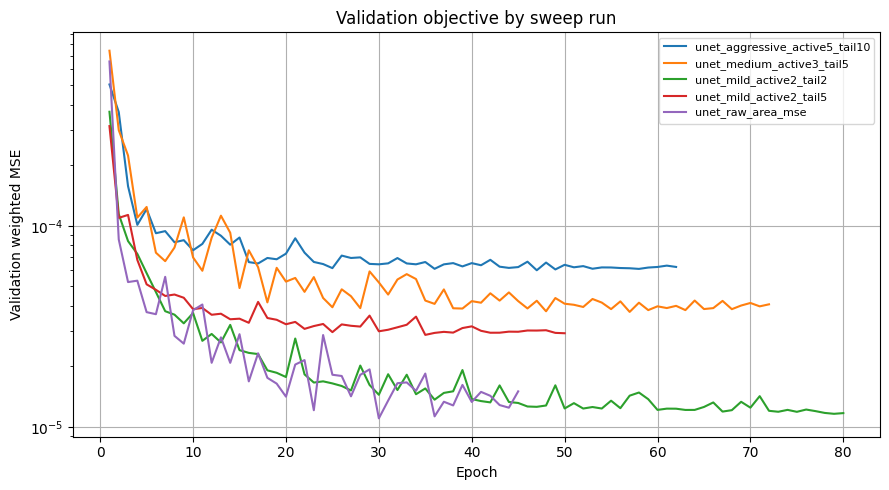

In [12]:
def plot_training_history(history_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, group in history_df.groupby("model"):
        group = group.sort_values("epoch")
        ax.plot(group["epoch"], group["val_weighted_mse"], label=model_name)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation weighted MSE")
    ax.set_title("Validation objective by sweep run")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_training_history(history_df)


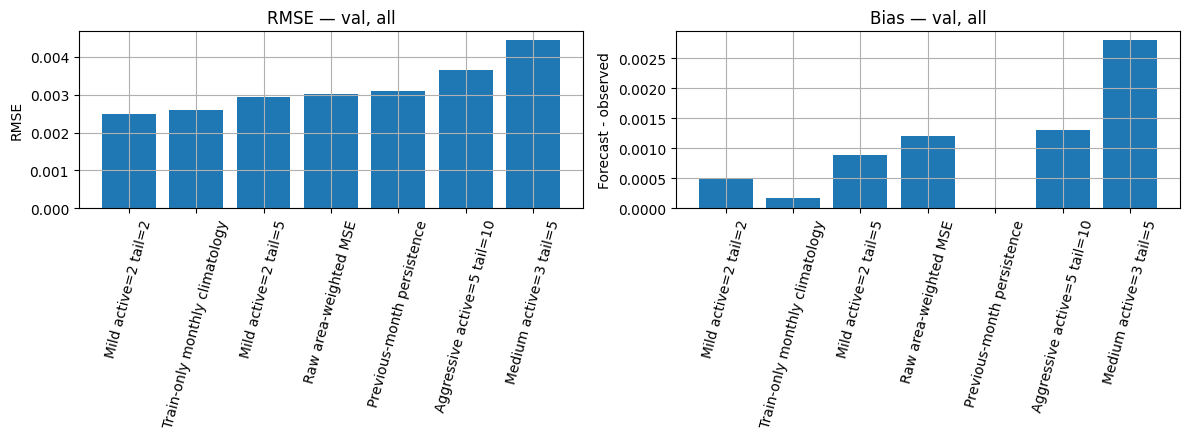

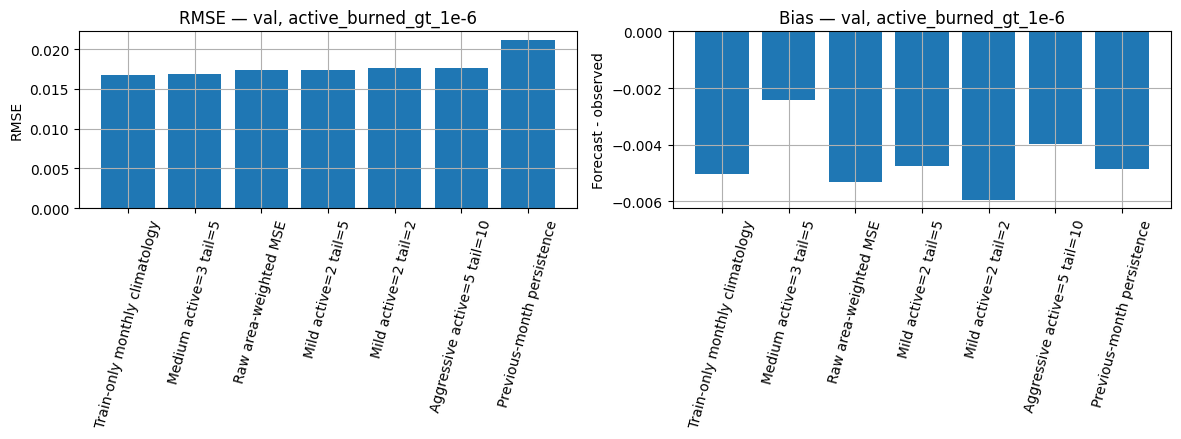

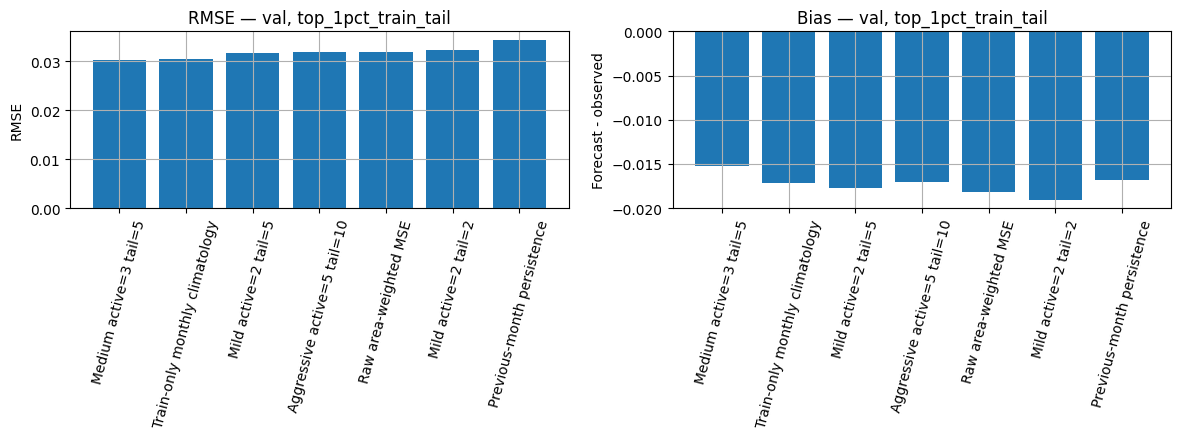

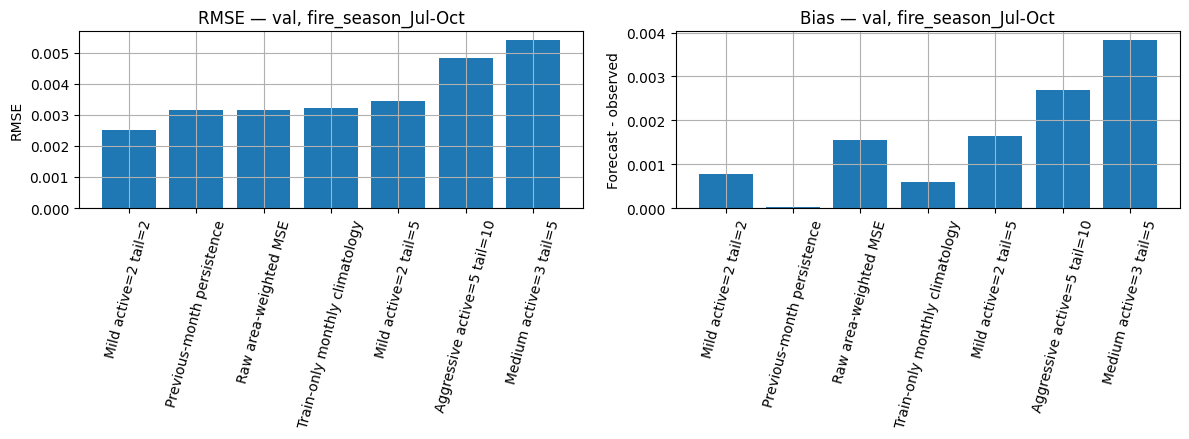

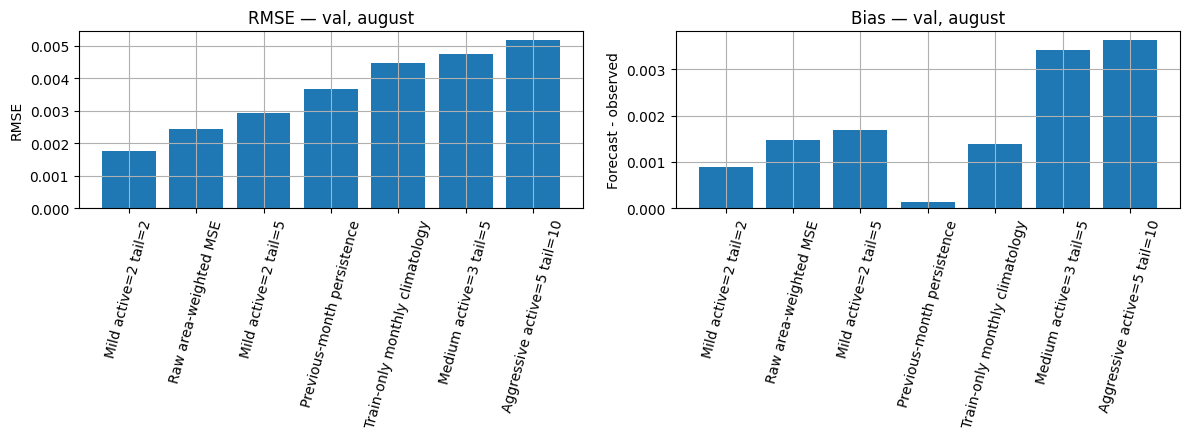

In [13]:
def plot_metric_bars(metrics_df: pd.DataFrame, split_name: str = "val", subset_name: str = "all") -> None:
    df = metrics_df[(metrics_df["split"] == split_name) & (metrics_df["subset"] == subset_name)].copy()
    if df.empty:
        print(f"No rows for split={split_name!r}, subset={subset_name!r}")
        return
    df = df.sort_values("rmse")
    labels = df.get("label", df["model"]).fillna(df["model"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
    axes[0].bar(labels, df["rmse"])
    axes[0].set_title(f"RMSE — {split_name}, {subset_name}")
    axes[0].set_ylabel("RMSE")
    axes[1].bar(labels, df["bias"])
    axes[1].set_title(f"Bias — {split_name}, {subset_name}")
    axes[1].set_ylabel("Forecast - observed")
    for ax in axes:
        ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    plt.show()


for subset_name in HEADLINE_SUBSETS:
    plot_metric_bars(metrics_df, split_name="val", subset_name=subset_name)

# Extra diagnostic views that are useful for wildfire season, but not part of the headline table.
plot_metric_bars(metrics_df, split_name="val", subset_name="fire_season_Jul-Oct")
plot_metric_bars(metrics_df, split_name="val", subset_name="august")


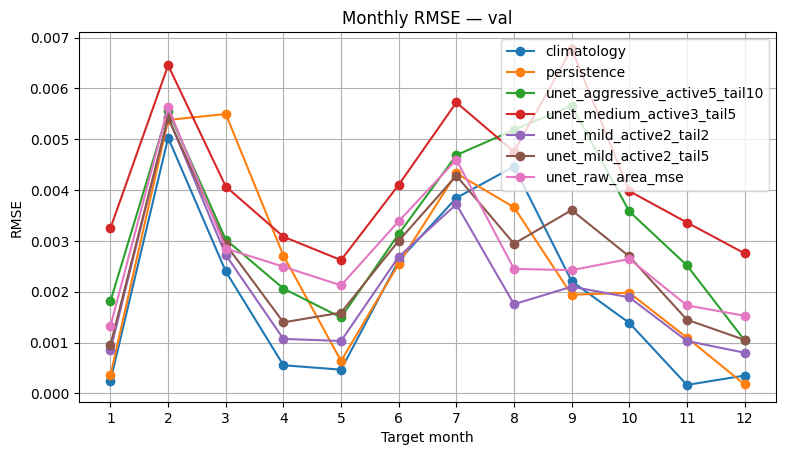

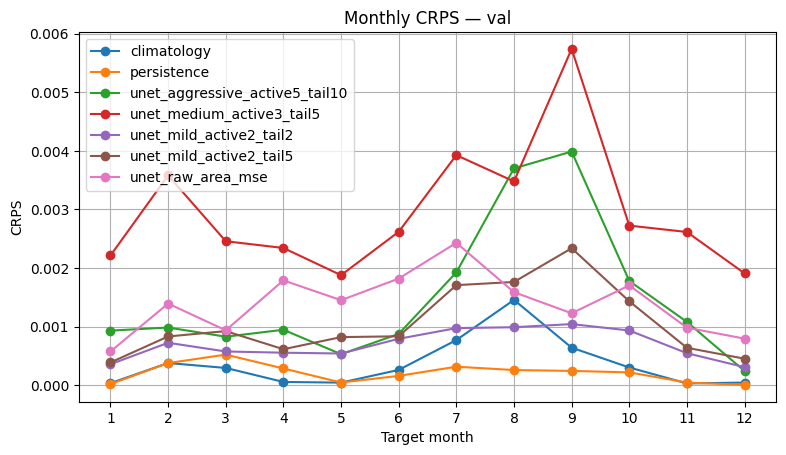

In [14]:
def plot_monthly_scores(monthly_df: pd.DataFrame, split_name: str = "val", metric: str = "rmse") -> None:
    df = monthly_df[monthly_df["split"] == split_name]
    if df.empty:
        print(f"No monthly rows for split={split_name!r}")
        return
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for model_name, group in df.groupby("model"):
        group = group.sort_values("month")
        ax.plot(group["month"], group[metric], marker="o", label=model_name)
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Target month")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Monthly {metric.upper()} — {split_name}")
    ax.legend()
    plt.show()


plot_monthly_scores(monthly_metrics_df, split_name="val", metric="rmse")
plot_monthly_scores(monthly_metrics_df, split_name="val", metric="crps")

### 10.3 Zero-cell false-positive diagnostics

This table checks whether a model improved active/tail metrics by raising predictions over cells that did not burn. It is computed on validation land cells with `target <= BURN_THRESHOLD` and saved as a CSV for analysis alongside the sweep metrics.

In [15]:
FALSE_POSITIVE_THRESHOLDS = (1e-4, 5e-4, 1e-3)


def zero_cell_false_positive_table(
    forecast_ens: xr.DataArray,
    observation: xr.DataArray,
    weights: xr.DataArray,
    model_name: str,
    split_name: str,
    thresholds: tuple[float, ...] = FALSE_POSITIVE_THRESHOLDS,
    member_dim: str = "member",
) -> pd.DataFrame:
    """Summarise forecast leakage into effectively unburned land cells.

    The condition uses target <= BURN_THRESHOLD so it is consistent with the
    active-burned subset definition used elsewhere in the notebook.
    """
    forecast_ens, observation = xr.align(forecast_ens, observation, join="inner")
    forecast_mean = forecast_ens.mean(member_dim, skipna=True).rename("forecast_mean")
    zero_condition = land_mask.broadcast_like(observation) & (observation <= BURN_THRESHOLD)

    row = {
        "model": model_name,
        "split": split_name,
        "zero_cell_definition": f"target <= {BURN_THRESHOLD:g}",
        "mean_prediction_zero_cells": weighted_masked_mean(forecast_mean, weights, zero_condition),
        "median_prediction_zero_cells": float(forecast_mean.where(zero_condition).median(skipna=True).values),
        "p95_prediction_zero_cells": float(forecast_mean.where(zero_condition).quantile(0.95, skipna=True).values),
        "p99_prediction_zero_cells": float(forecast_mean.where(zero_condition).quantile(0.99, skipna=True).values),
        "n_zero_cell_months": valid_cell_month_count(forecast_mean, weights, zero_condition),
    }
    for threshold in thresholds:
        exceedance = (forecast_mean > threshold).astype("float32")
        row[f"frac_zero_cells_pred_gt_{threshold:g}"] = weighted_masked_mean(exceedance, weights, zero_condition)
    return pd.DataFrame([row])


zero_fp_frames = []
for (model_name, split_name), forecast in all_forecasts.items():
    if split_name != "val":
        continue
    zero_fp_frames.append(
        zero_cell_false_positive_table(forecast, targets[split_name], area_weights, model_name, split_name)
    )

zero_fp_df = pd.concat(zero_fp_frames, ignore_index=True).merge(model_metadata_df, on="model", how="left")

# Add all-land context columns from the main metrics table.
all_land_context = metrics_df[(metrics_df["split"] == "val") & (metrics_df["subset"] == "all")][
    ["model", "rmse", "bias", "obs_mean", "forecast_mean"]
].rename(columns={
    "rmse": "all_land_rmse",
    "bias": "all_land_bias",
    "obs_mean": "all_land_obs_mean",
    "forecast_mean": "all_land_forecast_mean",
})
zero_fp_df = zero_fp_df.merge(all_land_context, on="model", how="left")

zero_false_positive_path = METRIC_DIR / "deterministic_unet_loss_weight_sweep_zero_cell_false_positives.csv"
zero_fp_df.to_csv(zero_false_positive_path, index=False)
print(f"Saved zero-cell false-positive diagnostics: {zero_false_positive_path}")

zero_display_cols = [
    "model", "label", "mean_prediction_zero_cells", "median_prediction_zero_cells",
    "p95_prediction_zero_cells", "p99_prediction_zero_cells",
    "frac_zero_cells_pred_gt_0.0001", "frac_zero_cells_pred_gt_0.0005", "frac_zero_cells_pred_gt_0.001",
    "all_land_rmse", "all_land_bias", "all_land_forecast_mean",
    "active_cell_loss_weight", "tail_cell_loss_weight",
]
display(zero_fp_df[zero_display_cols].sort_values("mean_prediction_zero_cells"))


Saved zero-cell false-positive diagnostics: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\metrics\deterministic_unet_loss_weight_sweep_zero_cell_false_positives.csv


,model,label,mean_prediction_zero_cells,median_prediction_zero_cells,p95_prediction_zero_cells,p99_prediction_zero_cells,frac_zero_cells_pred_gt_0.0001,frac_zero_cells_pred_gt_0.0005,frac_zero_cells_pred_gt_0.001,all_land_rmse,all_land_bias,all_land_forecast_mean,active_cell_loss_weight,tail_cell_loss_weight
6,persistence,Previous-month persistence,0.000078,0.000000,0.000000,0.000761,0.013462,0.011305,0.009749,0.003091,4.703991e-07,0.000112,NaN,NaN
5,climatology,Train-only monthly climatology,0.000259,0.000000,0.000936,0.005731,0.144363,0.075139,0.048234,0.002584,1.761352e-04,0.000288,NaN,NaN
1,unet_mild_active2_tail2,Mild active=2 tail=2,0.000602,0.000065,0.002688,0.004364,0.484481,0.355502,0.228097,0.002479,4.989343e-04,0.000610,2.0,2.0
2,unet_mild_active2_tail5,Mild active=2 tail=5,0.000972,0.000106,0.004269,0.007529,0.503510,0.412208,0.312517,0.002928,8.818196e-04,0.000993,2.0,5.0
0,unet_raw_area_mse,Raw area-weighted MSE,0.001308,0.000724,0.004643,0.007194,0.627979,0.548250,0.445204,0.003015,1.204166e-03,0.001316,1.0,1.0
4,unet_aggressive_active5_tail10,Aggressive active=5 tail=10,0.001391,0.000000,0.006529,0.011515,0.436260,0.391015,0.338340,0.003662,1.307341e-03,0.001419,5.0,10.0
3,unet_medium_active3_tail5,Medium active=3 tail=5,0.002889,0.002478,0.007515,0.010888,0.806369,0.765058,0.706487,0.004455,2.805510e-03,0.002917,3.0,5.0


### 10.4 Side-by-side validation maps

The first map uses the validation month with the largest total burned fraction across all months. The second map repeats the same comparison for the largest **fire-season** validation month only (`FIRE_SEASON_MONTHS = Jul-Oct` by default). This avoids selecting a winter/spring fire outlier as the only qualitative case.

Both maps compare the target against the references, the raw U-Net, the selected mild 2/2 candidate, and the medium 3/5 model that had stronger active/tail scores but worse background false positives.


Validation month with largest burned-fraction sum: 2019-02
Saved side-by-side map: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\figures\deterministic_unet\deterministic_unet_validation_201902_side_by_side_maps.png


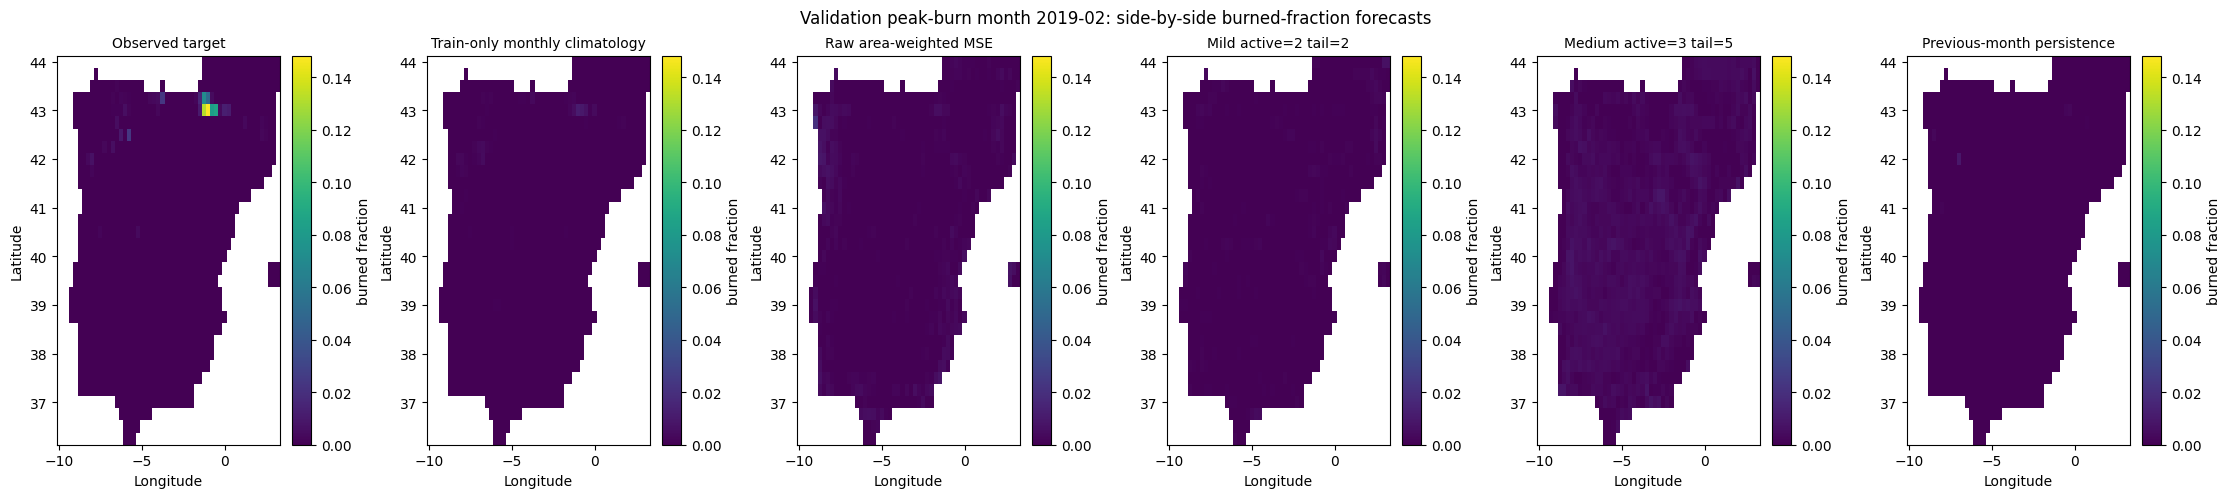

Validation fire-season month with largest burned-fraction sum (7,8,9,10): 2019-07
Saved side-by-side map: C:\Users\Usuario\Documents\GitProjects\Iberian-Wildfire-Forecasting\data\processed\figures\deterministic_unet\deterministic_unet_validation_fireseason_201907_side_by_side_maps.png


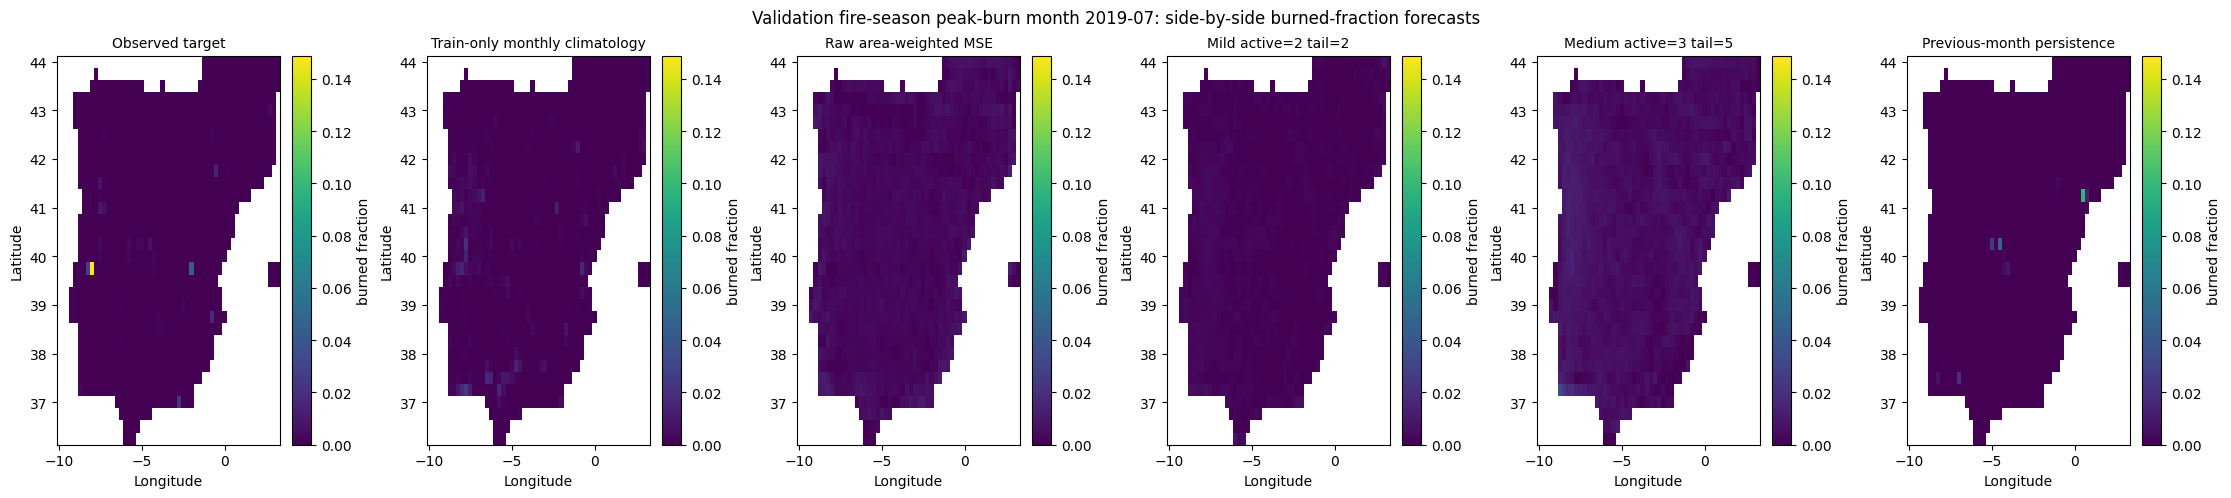

In [16]:
def _finite_max(da: xr.DataArray) -> float:
    values = np.asarray(da.values, dtype="float64")
    return float(np.nanmax(values)) if np.isfinite(values).any() else np.nan


def validation_month_with_max_burn(
    split_name: str = "val",
    months: tuple[int, ...] | None = None,
) -> pd.Timestamp:
    """Return the month with the largest land-masked burned-fraction sum.

    Parameters
    ----------
    split_name:
        Split to inspect, normally "val" for this notebook.
    months:
        Optional calendar-month filter. For example, use FIRE_SEASON_MONTHS
        to select the largest validation case among July-October only.
    """
    target = targets[split_name]
    if months is not None:
        month_mask = target.time.dt.month.isin(list(months))
        target = target.sel(time=month_mask)
    if target.sizes.get("time", 0) == 0:
        raise ValueError(f"No {split_name!r} months available for month filter: {months}")

    spatial_total = target.where(land_mask).sum(("lat", "lon"), skipna=True)
    idx = int(spatial_total.argmax("time").values)
    return pd.Timestamp(target.time.values[idx])


def _model_label(model_name: str) -> str:
    match = model_metadata_df.loc[model_metadata_df["model"] == model_name, "label"]
    return str(match.iloc[0]) if len(match) else model_name


def plot_side_by_side_forecast_maps(
    case_date: pd.Timestamp,
    split_name: str = "val",
    model_names: list[str] | None = None,
    save_path: Path | None = None,
    case_label: str = "Validation",
) -> None:
    """Plot observed burned fraction and selected model forecasts with a common scale."""
    if model_names is None:
        model_names = [
            "climatology",
            "unet_raw_area_mse",
            SELECTED_UNET_MODEL,
            "unet_medium_active3_tail5",
            "persistence",
        ]
    model_names = [m for m in model_names if (m, split_name) in all_forecasts]

    observed = targets[split_name].sel(time=case_date).where(land_mask)
    panel_data = [("Observed target", observed)]
    for model_name in model_names:
        forecast_map = all_forecasts[(model_name, split_name)].mean("member").sel(time=case_date).where(land_mask)
        panel_data.append((_model_label(model_name), forecast_map))

    burn_vmax = np.nanmax([_finite_max(panel) for _, panel in panel_data])
    if not np.isfinite(burn_vmax) or burn_vmax <= 0:
        burn_vmax = 1e-6

    n_panels = len(panel_data)
    fig, axes = plt.subplots(1, n_panels, figsize=(3.7 * n_panels, 4.6), constrained_layout=True)
    if n_panels == 1:
        axes = [axes]

    for ax, (title, da) in zip(axes, panel_data):
        da.plot(ax=ax, vmin=0.0, vmax=burn_vmax, cbar_kwargs={"label": "burned fraction"})
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    fig.suptitle(f"{case_label} {case_date:%Y-%m}: side-by-side burned-fraction forecasts", y=1.05)
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved side-by-side map: {save_path}")
    plt.show()


models_to_compare = [
    "climatology",
    "unet_raw_area_mse",
    SELECTED_UNET_MODEL,
    "unet_medium_active3_tail5",
    "persistence",
]

# Largest validation month across all calendar months.
case_date = validation_month_with_max_burn("val")
print(f"Validation month with largest burned-fraction sum: {case_date:%Y-%m}")
side_by_side_map_path = FIGURE_DIR / f"deterministic_unet_validation_{case_date:%Y%m}_side_by_side_maps.png"
plot_side_by_side_forecast_maps(
    case_date,
    split_name="val",
    model_names=models_to_compare,
    save_path=side_by_side_map_path,
    case_label="Validation peak-burn month",
)

# Largest validation month within the fire season only.
fire_season_case_date = validation_month_with_max_burn("val", months=FIRE_SEASON_MONTHS)
print(
    "Validation fire-season month with largest burned-fraction sum "
    f"({','.join(map(str, FIRE_SEASON_MONTHS))}): {fire_season_case_date:%Y-%m}"
)
fire_season_side_by_side_map_path = (
    FIGURE_DIR / f"deterministic_unet_validation_fireseason_{fire_season_case_date:%Y%m}_side_by_side_maps.png"
)
plot_side_by_side_forecast_maps(
    fire_season_case_date,
    split_name="val",
    model_names=models_to_compare,
    save_path=fire_season_side_by_side_map_path,
    case_label="Validation fire-season peak-burn month",
)


## 11. Artefacts written by this notebook

In [17]:
artefacts = []
for record in sweep_run_records:
    model_name = record["model"]
    artefacts.extend([
        {"kind": "model", "run_id": record["run_id"], "path": str(record["checkpoint_path"])},
        {"kind": "model_config", "run_id": record["run_id"], "path": str(record["config_path"])},
        {"kind": "training_history", "run_id": record["run_id"], "path": str(record["history_path"])},
        {"kind": "forecast", "run_id": record["run_id"], "path": str(FORECAST_DIR / f"{model_name}_forecast_val.nc")},
    ])
    if RUN_TEST_EVAL:
        artefacts.append({"kind": "forecast", "run_id": record["run_id"], "path": str(FORECAST_DIR / f"{model_name}_forecast_test.nc")})

artefacts.extend([
    {"kind": "training_summary", "run_id": "sweep", "path": str(sweep_training_summary_path)},
    {"kind": "combined_training_history", "run_id": "sweep", "path": str(history_path)},
    {"kind": "metrics_primary", "run_id": "sweep", "path": str(sweep_results_path)},
    {"kind": "metrics_headline", "run_id": "sweep", "path": str(headline_metrics_path)},
    {"kind": "metrics_monthly", "run_id": "sweep", "path": str(monthly_metrics_path)},
    {"kind": "zero_cell_false_positives", "run_id": "sweep", "path": str(zero_false_positive_path)},
    {"kind": "side_by_side_map", "run_id": "sweep", "path": str(side_by_side_map_path)},
    {"kind": "fire_season_side_by_side_map", "run_id": "sweep", "path": str(fire_season_side_by_side_map_path)},
    {"kind": "forecast", "run_id": "climatology", "path": str(FORECAST_DIR / "climatology_forecast_val.nc")},
    {"kind": "forecast", "run_id": "persistence", "path": str(FORECAST_DIR / "persistence_forecast_val.nc")},
])
display(pd.DataFrame(artefacts))


,kind,run_id,path
0,model,raw_area_mse,C:\Users\Usuario\Documents\GitProjects\Iberian...
1,model_config,raw_area_mse,C:\Users\Usuario\Documents\GitProjects\Iberian...
2,training_history,raw_area_mse,C:\Users\Usuario\Documents\GitProjects\Iberian...
3,forecast,raw_area_mse,C:\Users\Usuario\Documents\GitProjects\Iberian...
4,forecast,raw_area_mse,C:\Users\Usuario\Documents\GitProjects\Iberian...
5,model,mild_active2_tail2,C:\Users\Usuario\Documents\GitProjects\Iberian...
6,model_config,mild_active2_tail2,C:\Users\Usuario\Documents\GitProjects\Iberian...
7,training_history,mild_active2_tail2,C:\Users\Usuario\Documents\GitProjects\Iberian...
8,forecast,mild_active2_tail2,C:\Users\Usuario\Documents\GitProjects\Iberian...
9,forecast,mild_active2_tail2,C:\Users\Usuario\Documents\GitProjects\Iberian...


## 12. Deterministic U-Net baseline decision

I will use the sweep CSV, zero-cell false-positive CSV, and the all-month plus fire-season side-by-side maps to document the final validation choice.

Selected deterministic U-Net baseline:

```text
run_id = mild_active2_tail2
ACTIVE_CELL_LOSS_WEIGHT = 2.0
TAIL_CELL_LOSS_WEIGHT = 2.0
```

I've kept `RUN_TEST_EVAL = False` in this notebook. After this recipe is locked, I'll use a separate final-evaluation run to evaluate the frozen deterministic baseline on the reserved test years.
